# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json

# Load data

In [6]:
with open("..\\dataset\\results.json", 'r', encoding='utf-8') as f:
    results = json.load(f)
print(results)

[{'dimension': 64, 'recall_at_1': 0.475, 'recall_at_5': 0.775, 'recall_at_10': 0.85, 'latency': 0.04388378620147705}, {'dimension': 128, 'recall_at_1': 0.675, 'recall_at_5': 0.905, 'recall_at_10': 0.94, 'latency': 0.05073315620422363}, {'dimension': 256, 'recall_at_1': 0.74, 'recall_at_5': 0.895, 'recall_at_10': 0.96, 'latency': 0.050171374082565307}, {'dimension': 768, 'recall_at_1': 0.75, 'recall_at_5': 0.925, 'recall_at_10': 0.98, 'latency': 0.3423170566558838}]


In [4]:
embeddings_64 = np.load("..\\dataset\\document_embeddings_dim_64.npy")
print(embeddings_64.shape)
embeddings_128 = np.load("..\\dataset\\document_embeddings_dim_128.npy")
print(embeddings_128.shape)
embeddings_256 = np.load("..\\dataset\\document_embeddings_dim_256.npy")
print(embeddings_256.shape)
embeddings_768 = np.load("..\\dataset\\document_embeddings_dim_768.npy")
print(embeddings_768.shape)

(1000, 64)
(1000, 128)
(1000, 256)
(1000, 768)


# Visualize results

## Recall@k

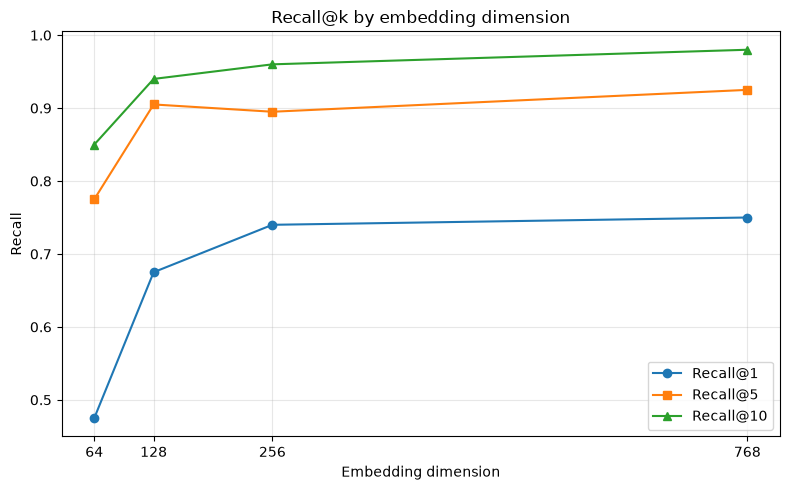

In [7]:
dimensions = [r["dimension"] for r in results]
recall_1 = [r["recall_at_1"] for r in results]
recall_5 = [r["recall_at_5"] for r in results]
recall_10 = [r["recall_at_10"] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(dimensions, recall_1, marker="o", label="Recall@1")
plt.plot(dimensions, recall_5, marker="s", label="Recall@5")
plt.plot(dimensions, recall_10, marker="^", label="Recall@10")

plt.xlabel("Embedding dimension")
plt.ylabel("Recall")
plt.title("Recall@k by embedding dimension")
plt.xticks(dimensions)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Embedding ranges

- figure inspired by: https://www.snowflake.com/en/blog/engineering/arctic-embed-m-v1-5-enterprise-retrieval/#snowflake-blog-author-chip-title

(64,) (64,)
(64,) (64,)
(128,) (128,)
(512,) (512,)


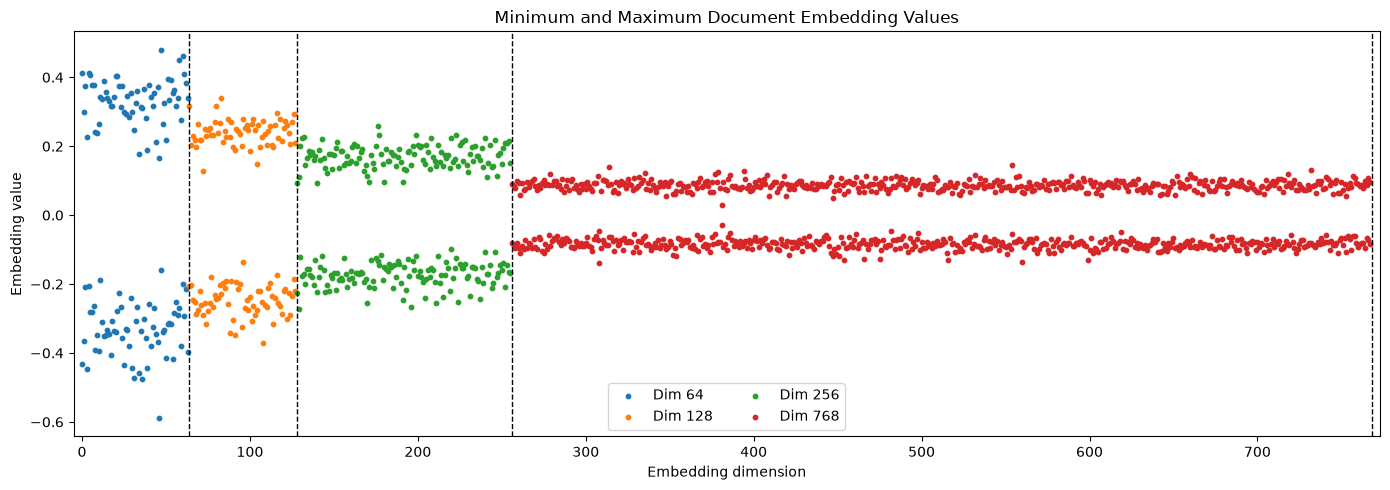

In [45]:
num_documents = embeddings_64.shape[0]
# prepare ranges, embedings, labels and colors
embedding_ranges = [
    (0, 64, embeddings_64, "64", "tab:blue"),
    (64, 128, embeddings_128, "128", "tab:orange"),
    (128, 256, embeddings_256, "256", "tab:green"),
    (256, 768, embeddings_768, "768", "tab:red"),
]

plt.figure(figsize=(14, 5))

for start, end, embedding_matrix, label, color in embedding_ranges:
    # For each dimension in the dimension range, we want to find the minimum and maximum values across all documents.
    minimums = embedding_matrix[:, start:end].min(axis=0)
    maximums = embedding_matrix[:, start:end].max(axis=0)
    print(minimums.shape, maximums.shape)

    dimensions = np.arange(start, end)
    # scatter plots like in the technical report for minimum and maximum values
    plt.scatter(dimensions, minimums, s=10, color=color, marker="o", label=f"Dim {label}")
    plt.scatter(dimensions, maximums, s=10, color=color, marker="o")

# Mark dimension boundaries
for boundary in [64, 128, 256, 768]:
    plt.axvline(
        boundary,
        color="black",
        linestyle="--",
        linewidth=1
    )

plt.xlabel("Embedding dimension")
plt.ylabel("Embedding value")
plt.title("Minimum and Maximum Document Embedding Values")
plt.xlim(-5, 773)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()